# Laboratorio CNNs-XAI - Hainer Mejía

## Preparación y carga de librerías 

In [51]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.16.2
NumPy: 1.26.4
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [52]:
import os
os.chdir('/Users/hainermejia/taller_cnn')
os.getcwd()

'/Users/hainermejia/taller_cnn'

## Ejercicio 1: Exploración del dataset

In [53]:
data_dir = "data"
clases = {"male": "data/male/Male Faces", "female": "data/female/Female Faces"}

for clase, ruta in clases.items():
    imagenes = os.listdir(ruta)
    print(f"Clase '{clase}': {len(imagenes)} imágenes")

Clase 'male': 2720 imágenes
Clase 'female': 2698 imágenes


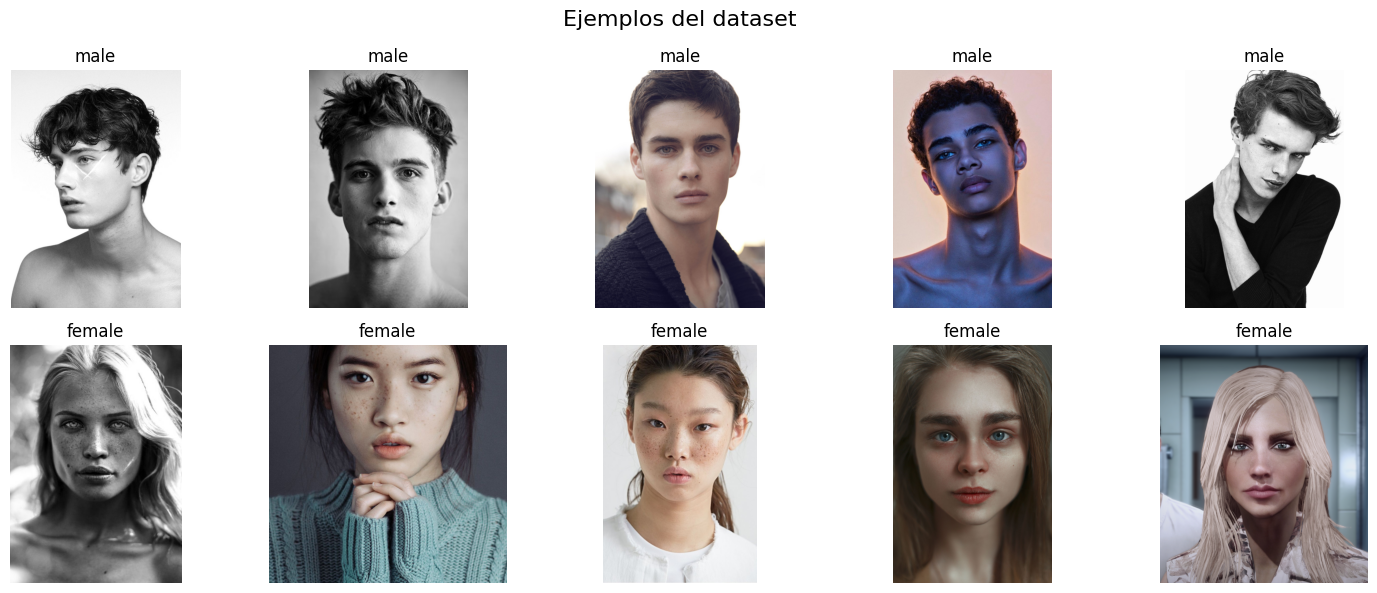

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Ejemplos del dataset", fontsize=16)

for i, (clase, ruta) in enumerate(clases.items()):
    imagenes = os.listdir(ruta)
    for j in range(5):
        img_path = os.path.join(ruta, imagenes[j])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(clase)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Verificar variabilidad de tamaños originales
for clase, ruta in clases.items():
    imagenes = os.listdir(ruta)
    tamaños = []
    for img_name in imagenes[:20]:  # muestra de 20
        img_path = os.path.join(ruta, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            tamaños.append(img.shape)
    print(f"\nClase '{clase}' — muestra de tamaños:")
    for t in set(tamaños):
        print(f"  {t}")


Clase 'male' — muestra de tamaños:
  (1488, 1000, 3)
  (1798, 1200, 3)
  (979, 736, 3)
  (1104, 736, 3)
  (700, 466, 3)
  (950, 699, 3)
  (640, 640, 3)
  (756, 500, 3)
  (1334, 952, 3)
  (470, 313, 3)
  (2213, 2987, 3)
  (720, 533, 3)
  (360, 480, 3)
  (1300, 1305, 3)
  (1600, 1180, 3)
  (937, 736, 3)
  (1120, 800, 3)
  (1920, 1280, 3)
  (700, 495, 3)

Clase 'female' — muestra de tamaños:
  (580, 600, 3)
  (2048, 1365, 3)
  (750, 500, 3)
  (442, 385, 3)
  (1024, 682, 3)
  (1194, 1300, 3)
  (5412, 8675, 3)
  (1024, 681, 3)
  (436, 350, 3)
  (1000, 1000, 3)
  (694, 500, 3)
  (1024, 661, 3)
  (1027, 735, 3)
  (1024, 683, 3)
  (1120, 750, 3)
  (396, 704, 3)
  (700, 500, 3)
  (800, 1200, 3)
  (1300, 953, 3)
  (1920, 1280, 3)


## Ejercicio 2: Preprocesamiento y partición

In [7]:
#Parámetros globles
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [8]:
#Cargar y preprocesar imágenes
from sklearn.model_selection import train_test_split

X, y = [], []

for label, (clase, ruta) in enumerate(clases.items()):
    for img_name in os.listdir(ruta):
        img_path = os.path.join(ruta, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Clases — male: {np.sum(y==0)}, female: {np.sum(y==1)}")

X shape: (5418, 224, 224, 3), y shape: (5418,)
Clases — male: 2720, female: 2698


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 3792 | Val: 813 | Test: 813


## Ejercicio 3: Construcción y entrenamiento del modelo CNN

In [61]:
# Construir modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/Users/hainermejia/taller_cnn/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Compilar modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [63]:
# Entrenar modelo
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step - accuracy: 0.7081 - loss: 0.6177 - val_accuracy: 0.8057 - val_loss: 0.4629
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.8357 - loss: 0.3780 - val_accuracy: 0.8967 - val_loss: 0.2703
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.9072 - loss: 0.2577 - val_accuracy: 0.9176 - val_loss: 0.2133
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.9312 - loss: 0.2192 - val_accuracy: 0.9348 - val_loss: 0.2649
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.9438 - loss: 0.2153 - val_accuracy: 0.9496 - val_loss: 0.3158
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.9604 - loss: 0.1956 - val_accuracy: 0.9631 - val_loss: 0.2619
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.9657 - loss: 0.2175 - val_accuracy: 0.9742 - val_loss: 0.3000
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.9736 - loss: 0

In [64]:
# Guardar modelo
os.makedirs('../models', exist_ok=True)
model.save('../models/model.keras')
print("Modelo guardado!")

Modelo guardado!


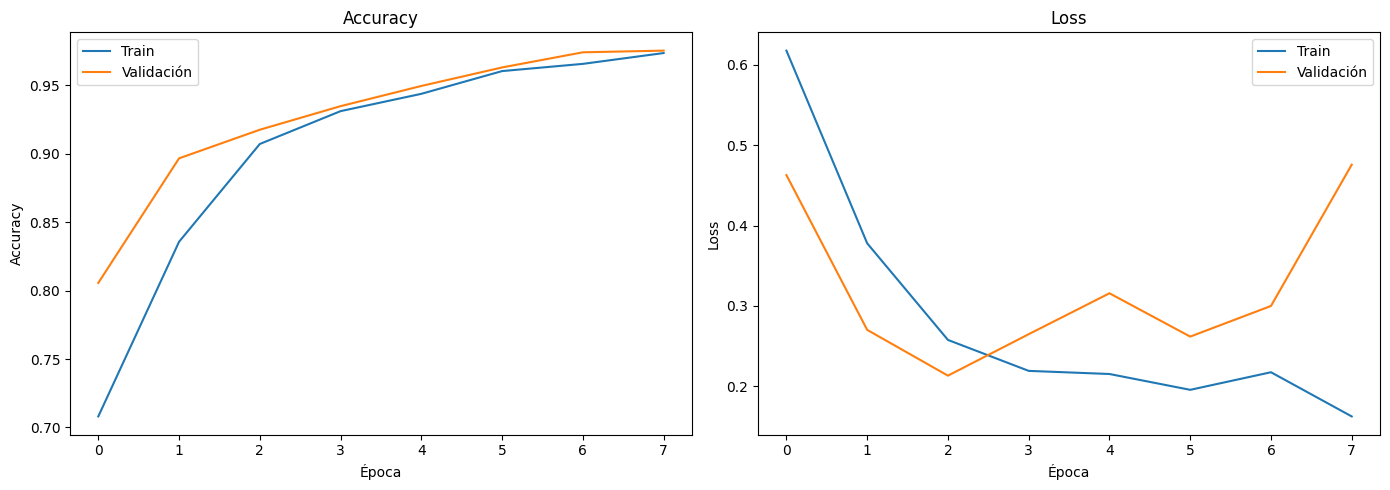

In [65]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Ejercicio 4: Ajuste de hiperparámetros

In [66]:
#Modelo A: Menos filtros, sin Batchnorm 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_A = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_A = model_A.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.6928 - loss: 0.6010 - val_accuracy: 0.8241 - val_loss: 0.3796
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8602 - loss: 0.3241 - val_accuracy: 0.9077 - val_loss: 0.2245
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9172 - loss: 0.2158 - val_accuracy: 0.9053 - val_loss: 0.3024
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9602 - loss: 0.1204 - val_accuracy: 0.9668 - val_loss: 0.1496
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9655 - loss: 0.1082 - val_accuracy: 0.9582 - val_loss: 0.2908
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.9673 - loss: 0.1226 - val_accuracy: 0.9348 - val_loss: 0.4495
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9697 - loss: 0.1569 - val_accuracy: 0.9569 - val_loss: 0.4149
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9612 - loss: 0.2375 - val_acc

In [67]:
# Modelo B: más filtros y learning rate más bajo
from tensorflow.keras.optimizers import Adam

model_B = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

history_B = model_B.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 479ms/step - accuracy: 0.6543 - loss: 0.6368 - val_accuracy: 0.8044 - val_loss: 0.4211
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 418ms/step - accuracy: 0.8012 - loss: 0.4298 - val_accuracy: 0.8672 - val_loss: 0.3226
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 419ms/step - accuracy: 0.8745 - loss: 0.3080 - val_accuracy: 0.8979 - val_loss: 0.2263
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 53s 449ms/step - accuracy: 0.9037 - loss: 0.2346 - val_accuracy: 0.9348 - val_loss: 0.1797
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 54s 457ms/step - accuracy: 0.9312 - loss: 0.1687 - val_accuracy: 0.9397 - val_loss: 0.1391
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 55s 459ms/step - accuracy: 0.9581 - loss: 0.1161 - val_accuracy: 0.9619 - val_loss: 0.1230
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 54s 455ms/step - accuracy: 0.9681 - loss: 0.0934 - val_accuracy: 0.9668 - val_loss: 0.1200
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 54s 456ms/step - accuracy: 0.9715 - loss: 0

In [68]:
# Comparación de los tres modelos
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
loss_A, acc_A = model_A.evaluate(X_test, y_test, verbose=0)
loss_B, acc_B = model_B.evaluate(X_test, y_test, verbose=0)

print(f"Modelo original — Test acc: {test_acc:.4f} | Test loss: {test_loss:.4f}")
print(f"Modelo A        — Test acc: {acc_A:.4f} | Test loss: {loss_A:.4f}")
print(f"Modelo B        — Test acc: {acc_B:.4f} | Test loss: {loss_B:.4f}")

Modelo original — Test acc: 0.9139 | Test loss: 0.2282
Modelo A        — Test acc: 0.9594 | Test loss: 0.1298
Modelo B        — Test acc: 0.9852 | Test loss: 0.0819


In [20]:
# Guardar modelos A y B también
model_A.save('../models/model_A.keras')
model_B.save('../models/model_B.keras')
print("Modelos A y B guardados!")

Modelos A y B guardados!


## Ejercicio 5: Interpretabilidad visual (Saliency Map y Grad-CAM)

Imagen 0 — Predicción: 0.0222 | Real: male | Pred: male


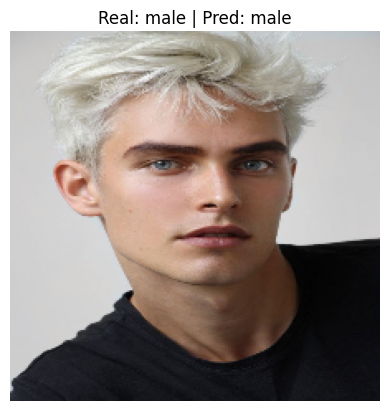

In [69]:
# Seleccionar una imagen correctamente clasificada para aplicar los mapas
predictions_all = model.predict(X_test, verbose=0)
pred_labels = (predictions_all > 0.5).astype(int).flatten()

img_idx = None
for i in range(len(X_test)):
    if pred_labels[i] == y_test[i]:
        img_idx = i
        break

img = X_test[img_idx]
pred_val = predictions_all[img_idx][0]
label_real = "male" if y_test[img_idx] == 0 else "female"
label_pred = "male" if pred_val < 0.5 else "female"
print(f"Imagen {img_idx} — Predicción: {pred_val:.4f} | Real: {label_real} | Pred: {label_pred}")

plt.imshow(img)
plt.title(f"Real: {label_real} | Pred: {label_pred}")
plt.axis('off')
plt.show()

Grad max: 0.0058018067


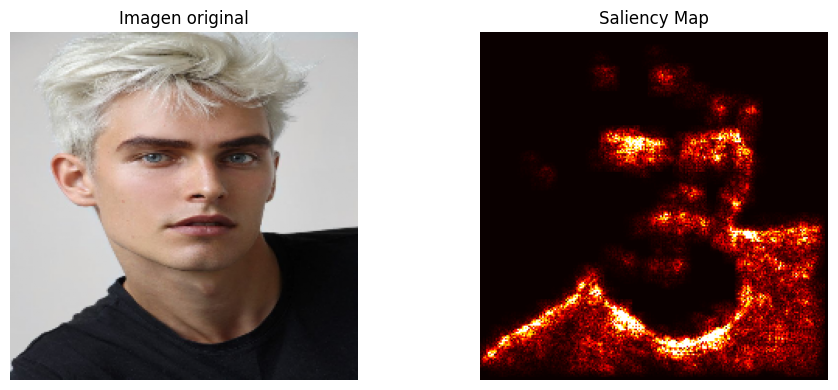

In [70]:
# Saliency Map: píxeles que más influyen en la decisión del modelo
img_tensor = tf.Variable(img[np.newaxis, ...], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    pred = model(img_tensor, training=False)

grads = tape.gradient(pred, img_tensor)
print("Grad max:", tf.reduce_max(tf.abs(grads)).numpy())

saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()
p99 = np.percentile(saliency, 99)
saliency = np.clip(saliency, 0, p99)
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.axis('off')
plt.tight_layout()
plt.show()

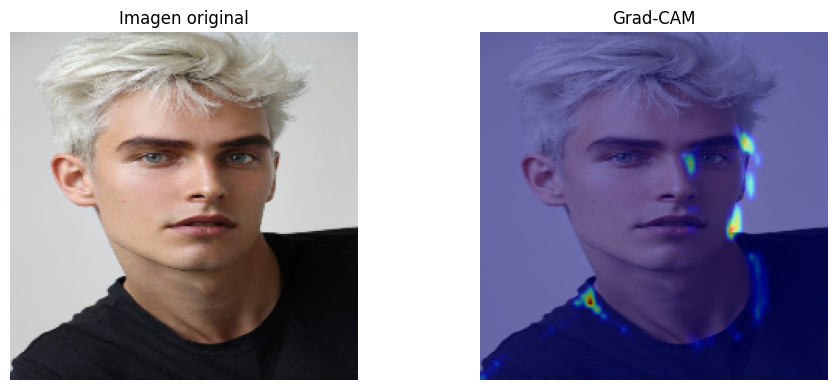

In [74]:
# Grad-CAM usando API funcional con pesos del modelo entrenado
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D(2,2)(x)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', name='last_conv')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_func = tf.keras.Model(inputs, outputs)
model_func.set_weights(model.get_weights())

feature_extractor = tf.keras.Model(
    inputs=model_func.input,
    outputs=[model_func.get_layer('last_conv').output, model_func.output]
)

img_const = tf.convert_to_tensor(img[np.newaxis, ...], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img_const)
    conv_outputs, preds = feature_extractor(img_const, training=False)
    loss = tf.reduce_sum(preds)

grads_cam = tape.gradient(loss, conv_outputs)[0]
pooled_grads = tf.reduce_mean(grads_cam, axis=(0, 1))
heatmap = (conv_outputs[0] @ pooled_grads[..., tf.newaxis])
heatmap = tf.squeeze(heatmap).numpy()
heatmap = np.maximum(heatmap, 0)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(cv2.resize(heatmap, (224, 224)), cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.tight_layout()
plt.show()

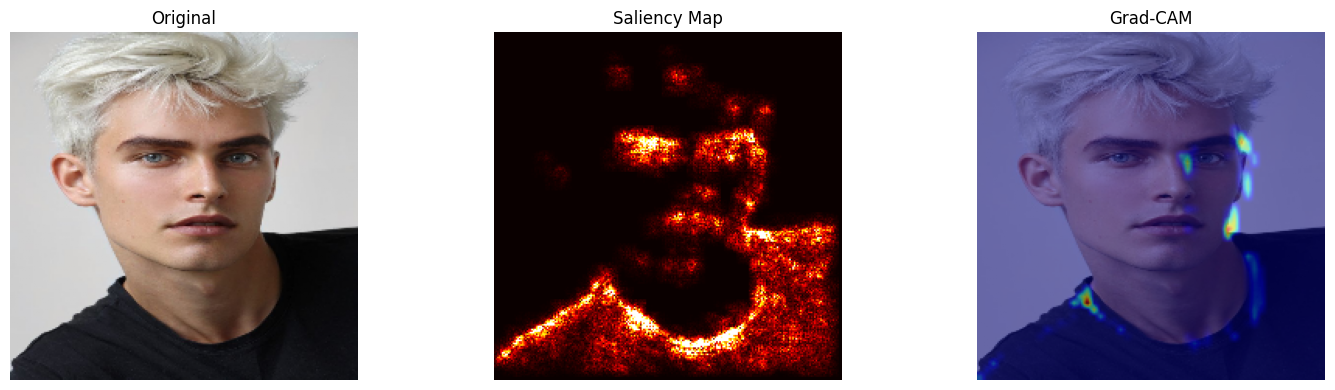

In [77]:
# Comparación lado a lado: imagen original, Saliency Map y Grad-CAM
heatmap_resized = cv2.resize(heatmap, (224, 224))

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.tight_layout()
plt.show()

## Ejercicio 6: Despliegue con Streamlit

## Ejercicio 7: Presentación y reflexión final